     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Train RMSE: 17.64
Test RMSE: 48.13


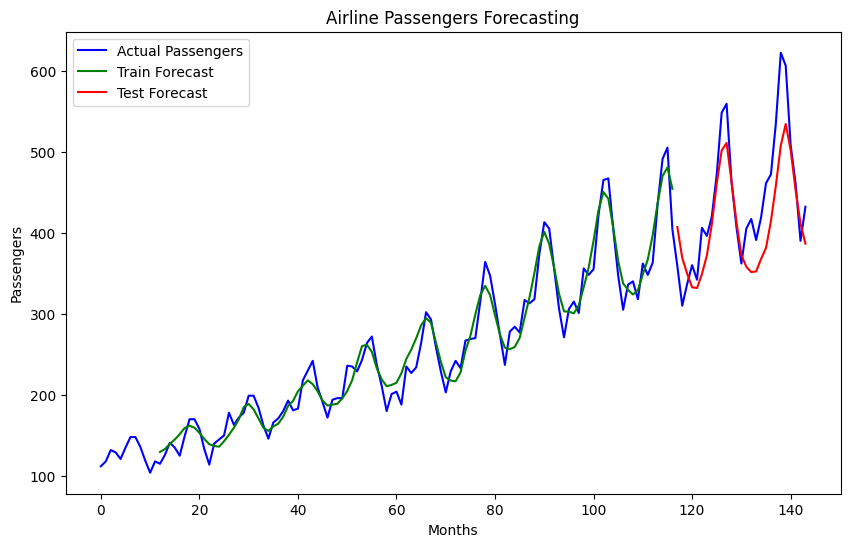

In [2]:
# Import Libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Step 1: Load Dataset dynamically in Colab
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url)
data = df['Passengers'].values.reshape(-1, 1).astype('float32')
print(df.head())

# Step 2: Scale the Data
# Corrected missing '=' operator
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Step 3: Create Lag Features (Sliding Window)
def create_dataset(dataset, lookback=12):
    X, y = [], []
    # Corrected missing '-' operator
    for i in range(len(dataset) - lookback):
        X.append(dataset[i:i + lookback, 0])
        y.append(dataset[i + lookback, 0])
    return np.array(X), np.array(y)

LOOKBACK = 12
X, y = create_dataset(scaled_data, LOOKBACK)

# Step 4 & 5: Train-Test Split and Reshape for LSTM
# Corrected missing '=' operator
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Step 6: Build and Train LSTM Model
# Removed activation='relu' to enforce cuDNN acceleration
model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, 1)),
    layers.LSTM(50, return_sequences=True),
    layers.LSTM(50),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=8,
    verbose=0
)

# Step 7 & 8: Forecast and Evaluate with RMSE
train_pred = model.predict(X_train)
# Corrected missing '=' operator
test_pred = model.predict(X_test)

train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_pred))

print(f'\nTrain RMSE: {train_rmse:.2f}')
print(f'Test RMSE: {test_rmse:.2f}')

# Visualization Logic
plt.figure(figsize=(10, 6))
plt.plot(scaler.inverse_transform(scaled_data), label='Actual Passengers', color='blue')

# Shift train predictions for plotting
train_plot = np.empty_like(scaled_data)
train_plot[:, :] = np.nan
train_plot[LOOKBACK:len(train_pred)+LOOKBACK, :] = train_pred
plt.plot(train_plot, label='Train Forecast', color='green')

# Shift test predictions for plotting
test_plot = np.empty_like(scaled_data)
test_plot[:, :] = np.nan
# Corrected indexing slice to precisely match the 27 test predictions
test_plot[len(train_pred) + LOOKBACK:len(scaled_data), :] = test_pred
plt.plot(test_plot, label='Test Forecast', color='red')

plt.title('Airline Passengers Forecasting')
plt.xlabel('Months')
plt.ylabel('Passengers')
plt.legend()
plt.show()